In [ ]:
!git clone https://github.com/CheckNanbang/2025-weather-data-contest.git

Cloning into '2025-weather-data-contest'...
remote: Enumerating objects: 600, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 600 (delta 76), reused 81 (delta 40), pack-reused 462 (from 2)
Receiving objects: 100% (600/600), 106.55 MiB | 15.21 MiB/s, done.
Resolving deltas: 100% (277/277), done.


In [ ]:
%cd 2025-weather-data-contest/
! git pull

/content/2025-weather-data-contest
Already up to date.


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 16.7 MB/s eta 0:00:00


In [ ]:
import os
import optuna
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from preproccesor import WeatherDataPreprocessor

warnings.filterwarnings(action='ignore', category=UserWarning)

# 시각화에 사용할 팔레트
plt.style.available

sns.color_palette("pastel")
sns.set(palette='pastel')

# 1. valid 확인

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Dataset path load
df_train =pd.read_csv('/content/drive/MyDrive/체크난방/weather_data_imputed2.csv')
df_train.head(3)

,tm,branch_id,ta,wd,ws,rn_day,rn_hr1,hm,si,ta_chi,...,date,year,month,day,hour,quarter,day_of_week,season,is_weekend,hour_group
0,2021-01-01 01:00:00,A,-10.1,78.3,0.5,0.0,0.0,68.2,0.0,-8.2,...,2021-01-01,2021,1,1,1,1,4,Winter,Weekday,0
1,2021-01-01 02:00:00,A,-10.2,71.9,0.6,0.0,0.0,69.9,0.0,-8.6,...,2021-01-01,2021,1,1,2,1,4,Winter,Weekday,0
2,2021-01-01 03:00:00,A,-10.0,360.0,0.0,0.0,0.0,69.2,0.0,-8.8,...,2021-01-01,2021,1,1,3,1,4,Winter,Weekday,1


In [ ]:
preprocessor = WeatherDataPreprocessor()

cluster_results = preprocessor.preprocess_data(df_train, is_test=False)
cluster0_df = cluster_results.get('cluster0')
cluster1_df = cluster_results.get('cluster1')
cluster2_summer_df = cluster_results.get('cluster2_summer')
cluster2_non_summer_df = cluster_results.get('cluster2_non_summer')
cluster3_df = cluster_results.get('cluster3')

데이터 전처리 시작...
cluster2_summer 전처리 중...
cluster2_non_summer 전처리 중...
cluster1 전처리 중...
cluster0 전처리 중...
cluster3 전처리 중...
클러스터별 데이터 전처리 완료!


In [ ]:
# GPU 연결 확인
!nvidia-smi

Thu Jun 26 16:46:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 1차 feature importance 추출 base code
- 유의한 변수에 가중치를 주기 위함


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 데이터 준비
df = cluster3_df.copy()
df = df.sort_values(["tm", "branch_id"]).reset_index(drop=True)

# 타겟 지정
target_col = "heat_demand"
y = df[target_col]

# object 컬럼 원핫 인코딩
object_cols = df.select_dtypes(include="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(df[object_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(object_cols))

# 나머지 수치형 변수
exclude_cols = object_cols + [target_col, "heat_demand", "heat_demand_log"]
numeric_df = df.drop(columns=exclude_cols)

# 최종 feature
X = pd.concat([numeric_df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

#cluster_3에만 추가한 온도,습도 상호작용항
X['temp_humidity_interaction'] = X['ta'] * X['hm']

X['tm'] = pd.to_datetime(X['tm'])  # 만약 이미 datetime이면 이 줄 생략

# 1시간 단위로 시간 블록 생성 (연-월-일-시까지 포함됨)
X['time_block'] = X['tm'].dt.strftime('%Y-%m-%d %H:00:00')

X = X.drop('tm',axis=1)

# 고유한 시간 블록 추출 및 정렬
time_blocks = np.sort(X['time_block'].unique())

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
rmse_list = []

for fold, (train_block_idx, val_block_idx) in enumerate(tscv.split(time_blocks), start=1):
    train_blocks = time_blocks[train_block_idx]
    val_blocks = time_blocks[val_block_idx]

    # 겹치는 시간 블록이 있다면 validation 앞부분에서 제거
    while len(val_blocks) > 0 and val_blocks[0] in train_blocks:
        val_blocks = val_blocks[1:]

    train_idx = X['time_block'].isin(train_blocks)
    val_idx = X['time_block'].isin(val_blocks)

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train = X_train.drop('time_block',axis=1)
    X_val = X_val.drop('time_block',axis=1)

    model = XGBRegressor(random_state=42, n_jobs=-1, tree_method="gpu_hist", predictor="gpu_predictor")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_list.append(rmse)
    print(f"[Fold {fold}] RMSE: {rmse:.4f}")

print(f"평균 RMSE: {np.mean(rmse_list):.4f}")

[Fold 1] RMSE: 9.1123
[Fold 2] RMSE: 5.4198
[Fold 3] RMSE: 3.9791
[Fold 4] RMSE: 4.8688
[Fold 5] RMSE: 3.9516
평균 RMSE: 5.4663


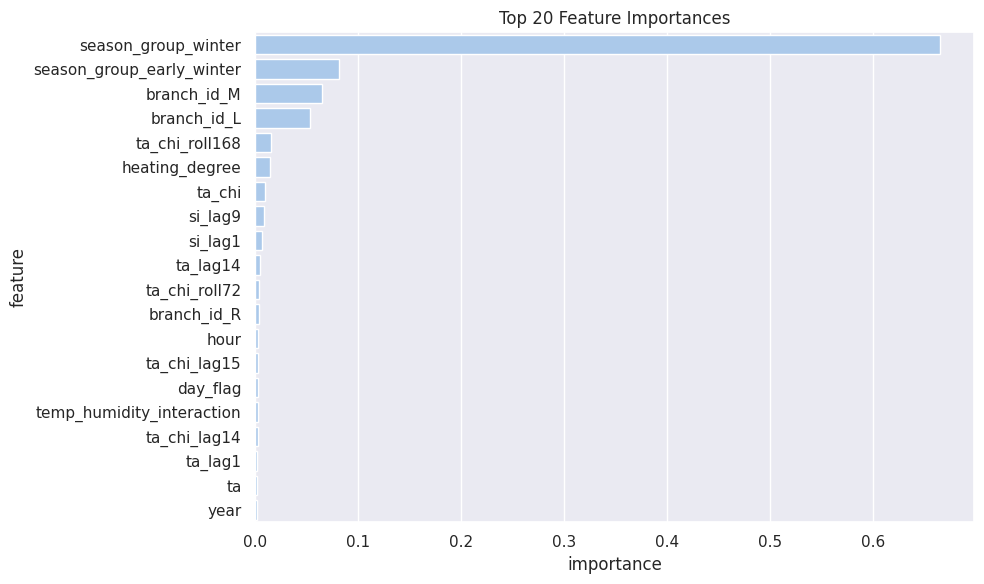

In [ ]:
X=X.drop('time_block',axis=1)

# feature importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance_df.head(20))  # 상위 20개
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# 중요도 기준 내림차순 정렬
importance_df_sorted = importance_df.sort_values(by="importance", ascending=False).reset_index(drop=True)

# 누적 중요도 열 추가
importance_df_sorted["cumulative_importance"] = importance_df_sorted["importance"].cumsum()

# 상위 96% 중요도를 차지하는 피처만 선택
top_features = importance_df_sorted[importance_df_sorted["cumulative_importance"] <= 0.96]
top_features = top_features["feature"].tolist()
len(top_features)

20

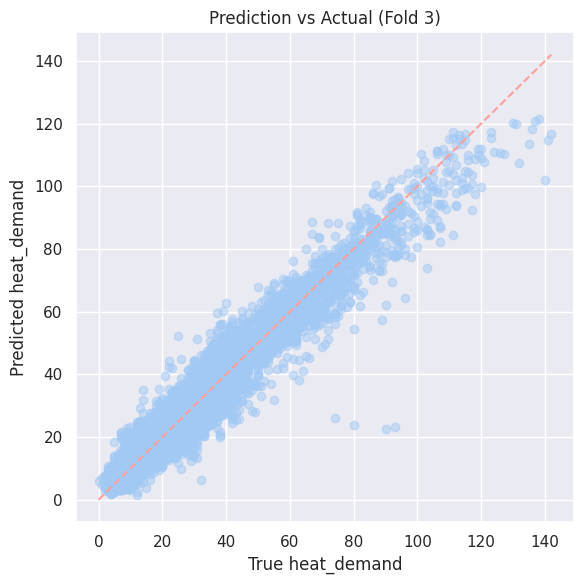

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("True heat_demand")
plt.ylabel("Predicted heat_demand")
plt.title("Prediction vs Actual (Fold 3)")
plt.grid(True)
plt.tight_layout()
plt.show()

2차 주요 변수
- 상위 96% 중요도를 차지하는 피처만 제곱하여 새로운 파생변수로 생성 후 2차 모델

In [ ]:
# 데이터 준비
df = cluster3_df.copy()
df['tm'] = pd.to_datetime(df['tm'])
df = df.sort_values(["tm", "branch_id"]).reset_index(drop=True)

# 타겟 지정
target_col = "heat_demand"
y = df[target_col]

# object 컬럼 원핫 인코딩
object_cols = df.select_dtypes(include="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(df[object_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(object_cols))

# 나머지 수치형 변수
exclude_cols = object_cols + [target_col, "heat_demand", "heat_demand_log"]
numeric_df = df.drop(columns=exclude_cols)

# 최종 feature
X = pd.concat([numeric_df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

#cluster_3에만 추가한 온도,습도 상호작용항
X['temp_humidity_interaction'] = X['ta'] * X['hm']

X['tm'] = pd.to_datetime(X['tm'])  # 만약 이미 datetime이면 이 줄 생략

# 1시간 단위로 시간 블록 생성 (연-월-일-시까지 포함됨)
X['time_block'] = X['tm'].dt.strftime('%Y-%m-%d %H:00:00')


for col in top_features:
    new_col = f'{col}_squared'
    X[new_col] = X[col] ** 2

X = X.drop('tm',axis=1)

# 고유한 시간 블록 추출 및 정렬
time_blocks = np.sort(X['time_block'].unique())

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
rmse_list = []

for fold, (train_block_idx, val_block_idx) in enumerate(tscv.split(time_blocks), start=1):
    train_blocks = time_blocks[train_block_idx]
    val_blocks = time_blocks[val_block_idx]

    # 겹치는 시간 블록이 있다면 validation 앞부분에서 제거
    while len(val_blocks) > 0 and val_blocks[0] in train_blocks:
        val_blocks = val_blocks[1:]

    train_idx = X['time_block'].isin(train_blocks)
    val_idx = X['time_block'].isin(val_blocks)

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train = X_train.drop('time_block',axis=1)
    X_val = X_val.drop('time_block',axis=1)

    model = XGBRegressor(random_state=42, n_jobs=-1, tree_method="gpu_hist", predictor="gpu_predictor")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_list.append(rmse)
    print(f"[Fold {fold}] RMSE: {rmse:.4f}")

print(f"평균 RMSE: {np.mean(rmse_list):.4f}")

[Fold 1] RMSE: 8.7919
[Fold 2] RMSE: 5.1087
[Fold 3] RMSE: 4.0246
[Fold 4] RMSE: 4.6343
[Fold 5] RMSE: 3.8833
평균 RMSE: 5.2886


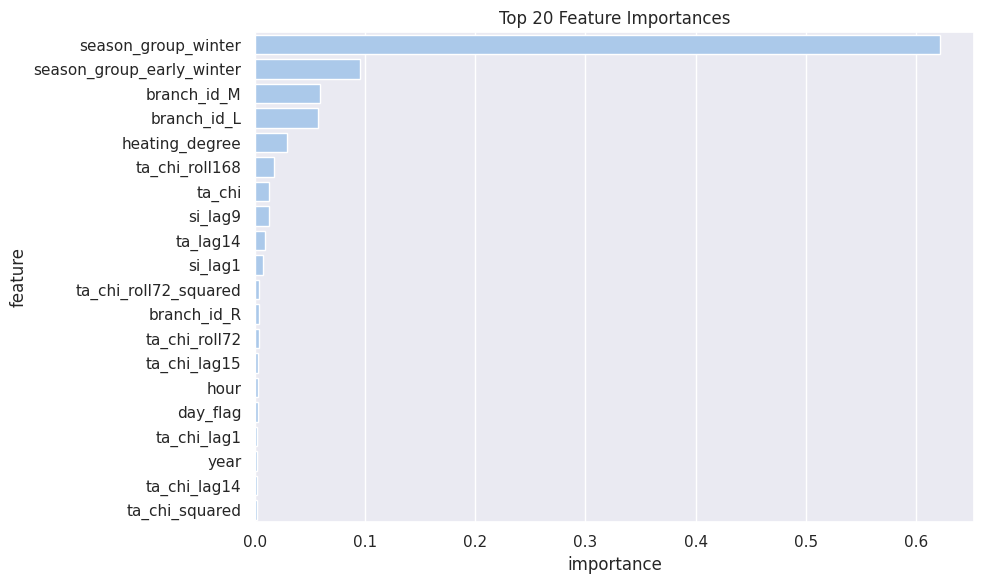

64

In [ ]:
X=X.drop('time_block',axis=1)

# feature importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance_df.head(20))  # 상위 20개
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

# 중요도 기준 내림차순 정렬
importance_df_sorted = importance_df.sort_values(by="importance", ascending=False).reset_index(drop=True)

# 누적 중요도 열 추가
importance_df_sorted["cumulative_importance"] = importance_df_sorted["importance"].cumsum()

# 상위 99% 중요도를 차지하는 피처만 선택
top_features2 = importance_df_sorted[importance_df_sorted["cumulative_importance"] <= 0.99] # 99%
top_features2 = top_features2["feature"].tolist()
len(top_features2)

In [ ]:
top_features2

['season_group_winter',
 'season_group_early_winter',
 'branch_id_M',
 'branch_id_L',
 'heating_degree',
 'ta_chi_roll168',
 'ta_chi',
 'si_lag9',
 'ta_lag14',
 'si_lag1',
 'ta_chi_roll72_squared',
 'branch_id_R',
 'ta_chi_roll72',
 'ta_chi_lag15',
 'hour',
 'day_flag',
 'ta_chi_lag1',
 'year',
 'ta_chi_lag14',
 'ta_chi_squared',
 'ta_lag1',
 'ta_chi_lag13',
 'ta_roll72',
 'ta',
 'branch_id_S',
 'ta_chi_lag14_squared',
 'ta_roll168',
 'si_lag2',
 'temp_humidity_interaction',
 'ta_chi_lag18',
 'coldwave',
 'si_roll3',
 'ta_roll24',
 'si_lag15',
 'ta_chi_lag17',
 'ta_zone_low',
 'ta_chi_lag6',
 'DI_interaction',
 'weekofyear',
 'ta_chi_roll24',
 'ta_lag11',
 'hour_cos',
 'ta_squared',
 'ta_lag2',
 'ta_lag24',
 'si',
 'ta_chi_lag2',
 'month',
 'ta_lag13',
 'month_cos',
 'ta_chi_lag3',
 'hour_of_week',
 'hour_sin',
 'ta_lag25',
 'si_lag19',
 'rn_day_lag9',
 'ta_lag23',
 'ta_chi_lag9',
 'ta_chi_lag12',
 'dew_point',
 'cumulative_si',
 'si_lag18',
 'si_lag5',
 'ta_lag7']

In [ ]:
#feature importance해서 나온 변수만 가지고 돌리기
X = X[top_features2]

# 튜닝 모델

최종 튜닝할 데이터는 1차 중요도 추출 후 제곱항 파생변수를 추가해주었고, 이후 2차 중요도 추출 후 상위 99% 만을 추출하여 모델링에 적용하였다.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Optuna 목적 함수 정의
def objective(trial):
    # 하이퍼파라미터 샘플링
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1
    }

    for fold, (train_block_idx, val_block_idx) in enumerate(tscv.split(time_blocks), start=1):
        train_blocks = time_blocks[train_block_idx]
        val_blocks = time_blocks[val_block_idx]

        # 겹치는 시간 블록이 있다면 validation 앞부분에서 제거
        while len(val_blocks) > 0 and val_blocks[0] in train_blocks:
            val_blocks = val_blocks[1:]

        # train_idx = X['time_block'].isin(train_blocks) #이전 코드에서 생성된 것 참조
        # val_idx = X['time_block'].isin(val_blocks)

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        sample_weight = np.log1p(np.expm1(y_train))

        # 스케일러 객체 생성
        scaler = StandardScaler()

        # X_train = X_train.drop('time_block',axis=1)
        # X_val = X_val.drop('time_block',axis=1)

        # fit_transform
        X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

        # transform
        X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

        model = model = XGBRegressor(
            **params,
            tree_method="gpu_hist",
            predictor="gpu_predictor"
        )
        model.fit(X_train, y_train, sample_weight =sample_weight )

        y_pred = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)

    return np.mean(rmse_list)

# Optuna 튜닝 실행
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

# 최적 하이퍼파라미터 출력
print("Best trial:")
print(study.best_trial)

[I 2025-06-26 15:32:40,153] A new study created in memory with name: no-name-2b0c2c89-c20a-42e3-9459-68e7ed1dd6aa
[I 2025-06-26 15:32:55,308] Trial 0 finished with value: 5.989661881858627 and parameters: {'n_estimators': 806, 'max_depth': 3, 'learning_rate': 0.004440818524777503, 'subsample': 0.7494609956311026, 'colsample_bytree': 0.8053943857695943, 'reg_alpha': 0.01488541046948605, 'reg_lambda': 3.4948977725528956e-08}. Best is trial 0 with value: 5.989661881858627.
[I 2025-06-26 15:33:16,389] Trial 1 finished with value: 5.397820196869401 and parameters: {'n_estimators': 826, 'max_depth': 6, 'learning_rate': 0.21041477174975043, 'subsample': 0.5060504395384295, 'colsample_bytree': 0.6163288571092191, 'reg_alpha': 3.7421535241482426e-08, 'reg_lambda': 0.014823095081964386}. Best is trial 1 with value: 5.397820196869401.
[I 2025-06-26 15:34:48,453] Trial 2 finished with value: 5.348181565332657 and parameters: {'n_estimators': 937, 'max_depth': 9, 'learning_rate': 0.0025878649091732

Best trial:
FrozenTrial(number=12, state=1, values=[4.5160721072643275], datetime_start=datetime.datetime(2025, 6, 26, 15, 38, 38, 358306), datetime_complete=datetime.datetime(2025, 6, 26, 15, 39, 1, 164600), params={'n_estimators': 602, 'max_depth': 7, 'learning_rate': 0.03878518685897426, 'subsample': 0.8613128362703897, 'colsample_bytree': 0.6347674724905161, 'reg_alpha': 9.545821121497825, 'reg_lambda': 1.258672944425539e-06}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'max_depth': IntDistribution(high=10, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'reg_alpha': FloatDistribution(high=10.0, log=True, low=1e-08, step=None), 'reg_lambda': FloatDistribution(high=10.0, log=True

In [ ]:
best_params =  {
    'n_estimators': 602,
    'max_depth': 7,
    'learning_rate': 0.03878518685897426,
    'subsample': 0.8613128362703897,
    'colsample_bytree': 0.6347674724905161,
    'reg_alpha': 9.545821121497825,
    'reg_lambda': 1.258672944425539e-06
}

# 최종 모델 및 test 생성

In [ ]:
# test 데이터 준비 및 전처리
df_test = pd.read_csv('/content/drive/MyDrive/지연_체크난방/non_null_test_data_dh.csv')  # test 데이터 불러오기
# 'tm' 열을 datetime 형식으로 파싱
df_test['tm'] = pd.to_datetime(df_test['tm'])

# 원하는 형식으로 출력 (예시로 바꾸는 것일 뿐 실제 데이터는 datetime형으로 유지)
df_test['tm'] = df_test['tm'].dt.strftime('%Y-%m-%d %H:%M:%S')
df_test

# 같은 WeatherDataPreprocessor를 써서 클러스터별로 분리한다고 가정
cluster_results_test = preprocessor.preprocess_data(df_test, is_test=True)
cluster3_test_df = cluster_results_test.get('cluster3')

# test 데이터 정렬 및 인덱스 재설정
df_test_cluster3 = cluster3_test_df.sort_values(["tm", "branch_id"]).reset_index(drop=True)

# test 데이터에서 object 컬럼 추출
object_cols_test = df_test_cluster3.select_dtypes(include="object").columns.tolist()

# train 때 사용한 encoder를 그대로 쓰기 때문에 여기서는 transform만 한다
encoded_array_test = encoder.transform(df_test_cluster3[object_cols_test])
encoded_df_test = pd.DataFrame(encoded_array_test, columns=encoder.get_feature_names_out(object_cols_test))

# 수치형 변수 추출
exclude_cols_test = object_cols_test + ["tm", "heat_demand","heat_demand_log"]  # test에는 타겟 없음
numeric_df_test = df_test_cluster3.drop(columns=exclude_cols_test)

# 최종 test 피처 구성
X_test = pd.concat([numeric_df_test.reset_index(drop=True), encoded_df_test.reset_index(drop=True)], axis=1)

#cluster_3에만 추가한 온도,습도 상호작용항
X_test['temp_humidity_interaction'] = X_test['ta'] * X_test['hm']

for col in top_features:
    new_col = f'{col}_squared'
    X_test[new_col] = X_test[col] ** 2

X_test = X_test[top_features2]

# train 데이터 전체로 최종 모델 학습
# 파라미터 설정 위에 했던 거 대로
model_final = XGBRegressor(random_state=42, n_jobs=-1, tree_method="gpu_hist", predictor="gpu_predictor" ,**best_params)
sample_weight = np.log1p(np.expm1(y))

# 스케일러 객체 생성
scaler = StandardScaler()

# fit_transform
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# transform
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


model_final.fit(X, y,sample_weight=sample_weight)


# test 데이터 예측
y_test_pred= model_final.predict(X_test)

# 결과 확인 (예: test 데이터에 예측 칼럼 추가)
df_test_cluster3['heat_demand_pred'] = y_test_pred

print(df_test_cluster3[['tm', 'branch_id', 'heat_demand_pred']].head())

# 3개 칼럼만 남기기
df_test_cluster3 = df_test_cluster3[['tm', 'branch_id', 'heat_demand_pred']]
df_test_cluster3

데이터 전처리 시작...
cluster2_summer 전처리 중...
cluster2_non_summer 전처리 중...
cluster1 전처리 중...
cluster0 전처리 중...
cluster3 전처리 중...
클러스터별 데이터 전처리 완료!
                   tm branch_id  heat_demand_pred
0 2024-01-01 00:00:00         L         54.540176
1 2024-01-01 00:00:00         M         75.876770
2 2024-01-01 00:00:00         R         31.704882
3 2024-01-01 00:00:00         S         25.392519
4 2024-01-01 01:00:00         L         48.623978


,tm,branch_id,heat_demand_pred
0,2024-01-01 00:00:00,L,54.540176
1,2024-01-01 00:00:00,M,75.876770
2,2024-01-01 00:00:00,R,31.704882
3,2024-01-01 00:00:00,S,25.392519
4,2024-01-01 01:00:00,L,48.623978
...,...,...,...
35135,2024-12-31 23:00:00,S,31.507080
35136,2025-01-01 00:00:00,L,64.906754
35137,2025-01-01 00:00:00,M,89.150009
35138,2025-01-01 00:00:00,R,37.163788


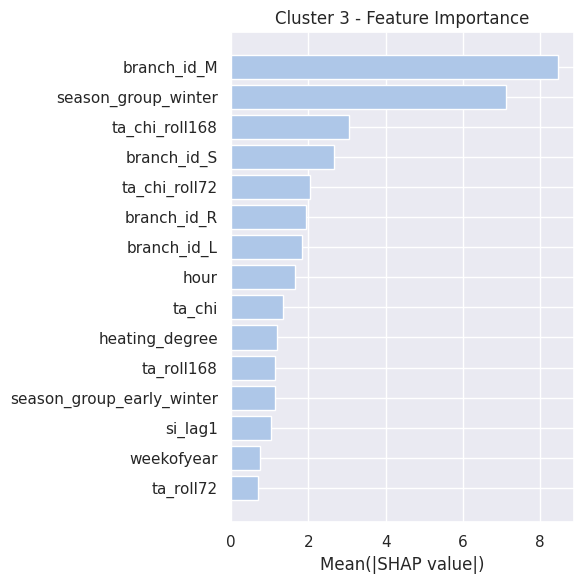

In [ ]:
import shap

# 1. SHAP Explainer 생성 및 SHAP 값 계산
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X)

# 2. SHAP 값 절댓값의 평균 구하기
mean_shap = np.abs(shap_values).mean(axis=0)
feature_names = X.columns

# 3. 상위 15개 feature
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'MeanAbsSHAP': mean_shap
}).sort_values(by='MeanAbsSHAP', ascending=False).head(15)

# 4. bar plot 그리기
plt.figure(figsize=(6, 6))
bars = plt.barh(shap_df['Feature'][::-1], shap_df['MeanAbsSHAP'][::-1], color='#aec7e8')
plt.xlabel('Mean(|SHAP value|)')
plt.title('Cluster 3 - Feature Importance')
plt.tight_layout()
plt.show()